# 01 - Preprocess, EDA, and Feature Engineering

Goal: audit the NIFTY-50 dataset, clean the combined price history, attach metadata, engineer technical indicators, and save a reusable modeling dataset.

In [8]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from invest_intel.data import attach_metadata, dataset_audit, load_metadata, load_prices, save_processed
from invest_intel.features import add_technical_features

## Dataset Audit

In [9]:
audit = dataset_audit()
audit

{'rows': 235192,
 'columns': ['date',
  'symbol',
  'series',
  'prev_close',
  'open',
  'high',
  'low',
  'last',
  'close',
  'vwap',
  'volume',
  'turnover',
  'trades',
  'deliverable_volume',
  'deliverable_pct'],
 'date_min': '2000-01-03',
 'date_max': '2021-04-30',
 'price_symbol_count': 65,
 'metadata_symbol_count': 50,
 'metadata_industry_count': 13,
 'symbols_without_metadata': ['BAJAUTOFIN',
  'BHARTI',
  'HEROHONDA',
  'HINDALC0',
  'HINDLEVER',
  'INFOSYSTCH',
  'JSWSTL',
  'KOTAKMAH',
  'MUNDRAPORT',
  'SESAGOA',
  'SSLT',
  'TELCO',
  'TISCO',
  'UNIPHOS',
  'UTIBANK',
  'ZEETELE'],
 'metadata_without_prices': ['INFRATEL'],
 'tiny_csv_files': ['INFRATEL.csv'],
 'top_missing': {'trades': 114848,
  'deliverable_volume': 16077,
  'deliverable_pct': 16077,
  'prev_close': 0,
  'date': 0,
  'symbol': 0,
  'series': 0,
  'low': 0}}

In [10]:
prices = load_prices()
metadata = load_metadata()
prices_with_meta = attach_metadata(prices, metadata)

display(prices_with_meta.head())
display(metadata['industry'].value_counts())

,date,symbol,series,prev_close,open,high,low,last,close,vwap,volume,turnover,trades,deliverable_volume,deliverable_pct,company_name,industry,isin_code
0,2012-01-17,ADANIPORTS,EQ,135.5,137.1,141.00,135.00,140.1,140.00,138.13,1636196,2.260074e+13,18374.0,1004327.0,0.6138,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
1,2012-01-18,ADANIPORTS,EQ,140.0,142.0,143.80,138.70,143.0,141.70,141.25,890591,1.257986e+13,15615.0,404925.0,0.4547,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
2,2012-01-19,ADANIPORTS,EQ,141.7,144.0,150.55,143.15,149.5,149.40,146.72,1456077,2.136382e+13,31299.0,721545.0,0.4955,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
3,2012-01-20,ADANIPORTS,EQ,149.4,151.9,157.60,150.25,155.4,155.40,153.76,1634070,2.512583e+13,23335.0,861145.0,0.5270,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
4,2012-01-23,ADANIPORTS,EQ,155.4,155.4,155.40,145.10,146.4,146.75,149.54,1657609,2.478768e+13,12400.0,820653.0,0.4951,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042


industry
FINANCIAL SERVICES          9
ENERGY                      7
AUTOMOBILE                  6
CONSUMER GOODS              6
METALS                      5
IT                          5
PHARMA                      3
CEMENT & CEMENT PRODUCTS    3
TELECOM                     2
SERVICES                    1
CONSTRUCTION                1
FERTILISERS & PESTICIDES    1
MEDIA & ENTERTAINMENT       1
Name: count, dtype: int64

## EDA Checks

In [11]:
coverage = (
    prices_with_meta.groupby('symbol')
    .agg(start=('date', 'min'), end=('date', 'max'), rows=('date', 'size'), missing_close=('close', lambda s: s.isna().sum()))
    .sort_values('rows')
)
coverage.head(15)

,start,end,rows,missing_close
symbol,,,,
JSWSTL,2005-03-23,2005-09-15,123,0
SSLT,2013-10-04,2015-05-06,388,0
KOTAKMAH,2000-01-03,2003-04-17,502,0
TELCO,2000-01-03,2003-12-24,999,0
MUNDRAPORT,2007-11-27,2012-01-16,1023,0
BHARTI,2002-02-18,2006-06-16,1089,0
TISCO,2000-01-03,2005-10-14,1455,0
VEDL,2015-05-07,2021-04-30,1482,0
ZEETELE,2000-01-03,2007-02-27,1796,0


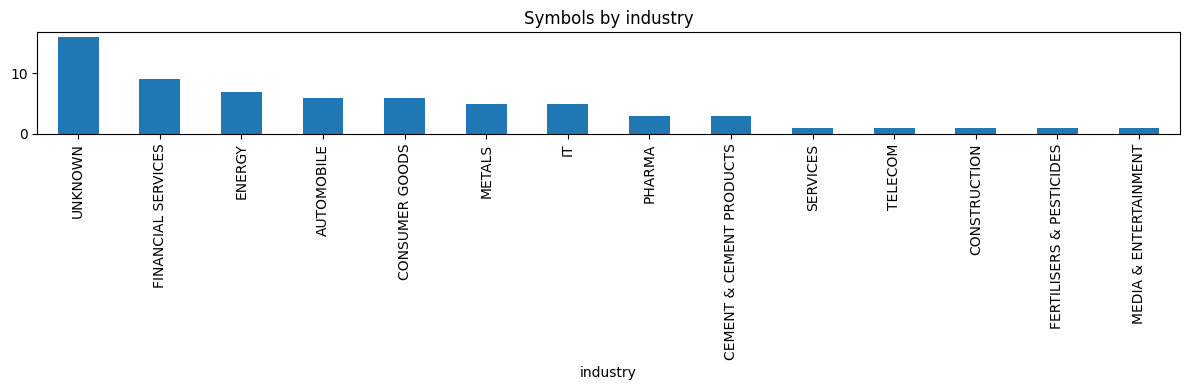

In [12]:
sector_counts = prices_with_meta.drop_duplicates('symbol')['industry'].fillna('UNKNOWN').value_counts()
sector_counts.plot(kind='bar', figsize=(12, 4), title='Symbols by industry')
plt.tight_layout()

## Feature Engineering

In [13]:
features = add_technical_features(prices_with_meta)
display(features.filter(regex='date|symbol|close|return|rsi|macd|volatility').head())
features.shape

,date,symbol,prev_close,close,daily_return,log_return,close_to_vwap,gap_return,close_to_ma_5,close_to_ma_20,...,close_to_ma_100,volatility_10,volatility_20,volatility_60,macd,macd_signal,rsi_14,future_return_1d,future_return_5d,future_return_21d
0,2012-01-17,ADANIPORTS,135.5,140.00,NaN,NaN,0.013538,0.011808,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.012143,0.071786,0.054286
1,2012-01-18,ADANIPORTS,140.0,141.70,0.012143,0.012070,0.003186,0.014286,NaN,NaN,...,NaN,NaN,NaN,NaN,0.135613,0.027123,NaN,0.054340,0.010586,0.062103
2,2012-01-19,ADANIPORTS,141.7,149.40,0.054340,0.052915,0.018266,0.016231,NaN,NaN,...,NaN,NaN,NaN,NaN,0.854561,0.192610,NaN,0.040161,-0.015395,0.021754
3,2012-01-20,ADANIPORTS,149.4,155.40,0.040161,0.039375,0.010666,0.016734,NaN,NaN,...,NaN,NaN,NaN,NaN,1.886734,0.531435,NaN,-0.055663,-0.109395,-0.074324
4,2012-01-23,ADANIPORTS,155.4,146.75,-0.055663,-0.057272,-0.018657,0.000000,0.000682,NaN,...,NaN,NaN,NaN,NaN,1.983887,0.821925,NaN,0.022487,-0.003407,-0.018399


(235192, 52)

In [14]:
out_path = save_processed(features, 'nifty50_features.csv')
out_path

WindowsPath('E:/Projects/cult_invest_intel_ml/data/processed/nifty50_features.csv')